Uploading

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Loaded:", df.shape)
df.head()

Saving Air Astana 2024-26 Stock Price History.csv to Air Astana 2024-26 Stock Price History (1).csv
Loaded: (526, 7)


,Date,Price,Open,High,Low,Vol.,Change %
0,03/06/2026,6.42,6.42,6.44,6.42,16.83K,0.31%
1,03/05/2026,6.40,6.40,6.50,6.40,19.60K,0.31%
2,03/04/2026,6.38,6.58,6.58,6.32,17.57K,-1.85%
3,03/03/2026,6.50,6.60,6.60,6.50,33.51K,-1.52%
4,03/02/2026,6.60,6.60,6.70,6.60,7.00K,0.92%


Preprocessing

In [3]:
# convert date
df['Date'] = pd.to_datetime(df['Date'])

# sort chronologically
df = df.sort_values('Date')

# select price column
df = df[['Date', 'Price']]
df.columns = ['Date', 'Close']

# ensure numeric
df['Close'] = df['Close'].astype(float)

df.head()

,Date,Close
525,2024-02-12,9.4
524,2024-02-13,9.5
523,2024-02-14,9.5
522,2024-02-15,10.0
521,2024-02-16,10.0


Standartization

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Close_scaled'] = scaler.fit_transform(df[['Close']])

data = df['Close_scaled'].values

Sequence creation

In [5]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

LSTM train function

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def train_lstm(window_size):
    print(f"\n=== WINDOW SIZE: {window_size} ===")

    X, y = create_sequences(data, window_size)

    # reshape (samples, timesteps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # chronological split
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # model
    model = Sequential([
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(1)  # linear
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # evaluation
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print("MAE:", mae)
    print("RMSE:", rmse)

    # plot
    plt.figure(figsize=(10,4))
    plt.plot(y_test[:200], label="True")
    plt.plot(preds[:200], label="Predicted")
    plt.legend()
    plt.title(f"LSTM Predictions (window={window_size})")
    plt.show()

    return model, mae, rmse

Windows 12/24


=== WINDOW SIZE: 12 ===
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.7306 - mae: 0.6951 - val_loss: 0.1103 - val_mae: 0.2721
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1191 - mae: 0.2735 - val_loss: 0.0684 - val_mae: 0.2066
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0804 - mae: 0.2177 - val_loss: 0.0429 - val_mae: 0.1723
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0631 - mae: 0.1905 - val_loss: 0.0373 - val_mae: 0.1689
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0595 - mae: 0.1935 - val_loss: 0.0380 - val_mae: 0.1679
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0542 - mae: 0.1782 - val_loss: 0.0385 - val_mae: 0.1651
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0519 - mae: 0.1768 - val_loss: 0.0353 - val_mae: 0.1623
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0500 - mae: 0.1718 - val_loss: 0.0354 - val_mae: 0.1568
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0

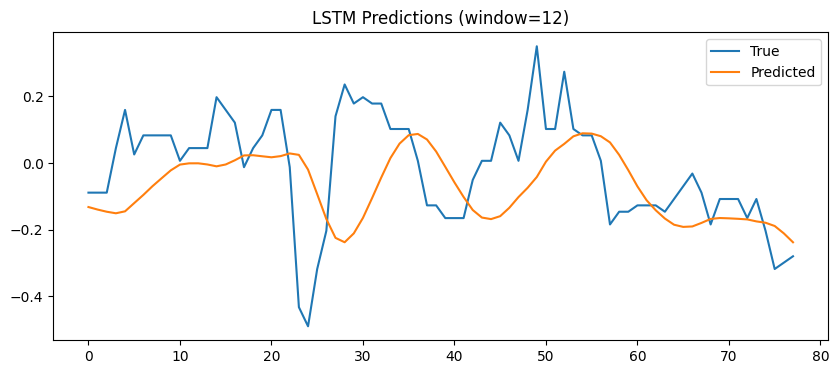


=== WINDOW SIZE: 24 ===
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.3275 - mae: 0.4375 - val_loss: 0.1182 - val_mae: 0.2734
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0895 - mae: 0.2325 - val_loss: 0.0548 - val_mae: 0.1958
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0681 - mae: 0.2057 - val_loss: 0.0440 - val_mae: 0.1874
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0549 - mae: 0.1827 - val_loss: 0.0640 - val_mae: 0.2036
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0517 - mae: 0.1799 - val_loss: 0.0481 - val_mae: 0.1836
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0503 - mae: 0.1737 - val_loss: 0.0432 - val_mae: 0.1745
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0478 - mae: 0.1697 - val_loss: 0.0440 - val_mae: 0.1692
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0481 - mae: 0.1706 - val_loss: 0.0395 - val_mae: 0.1596
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 

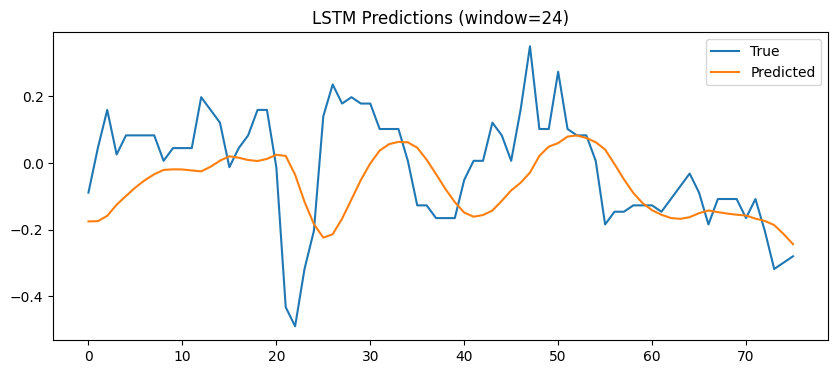

In [7]:
results = {}

for w in [12, 24]:
    model, mae, rmse = train_lstm(w)
    results[w] = {"MAE": mae, "RMSE": rmse}

Comparing results

In [9]:
print("\n=== RESULTS ===")
for w, res in results.items():
    print(f"Window {w}: MAE={res['MAE']:.4f}, RMSE={res['RMSE']:.4f}")


=== RESULTS ===
Window 12: MAE=0.1691, RMSE=0.2040


Saving the best model

Best window: 12

=== WINDOW SIZE: 12 ===
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.5550 - mae: 0.6090 - val_loss: 0.0779 - val_mae: 0.2336
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0968 - mae: 0.2474 - val_loss: 0.0637 - val_mae: 0.1981
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0688 - mae: 0.2041 - val_loss: 0.0409 - val_mae: 0.1760
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0612 - mae: 0.1886 - val_loss: 0.0403 - val_mae: 0.1757
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0572 - mae: 0.1887 - val_loss: 0.0402 - val_mae: 0.1742
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0523 - mae: 0.1769 - val_loss: 0.0397 - val_mae: 0.1739
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0516 - mae: 0.1739 - val_loss: 0.0394 - val_mae: 0.1687
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0499 - mae: 0.1718 - val_loss: 0.0360 - val_mae: 0.1647
Epoch 9/20
12/12 ━━━━━━

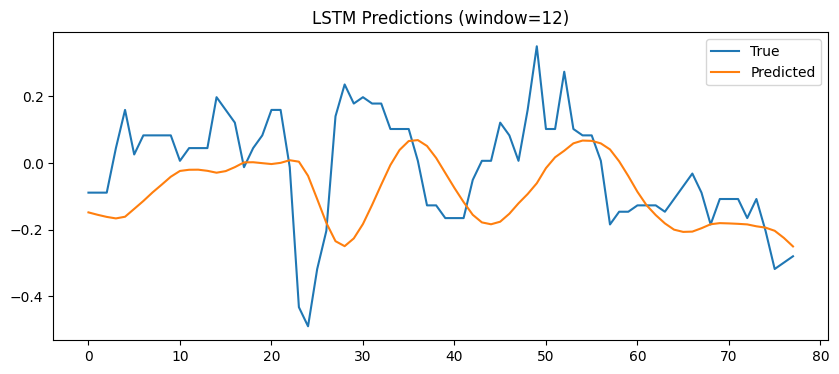


Best model saved!
Best MAE: 0.1410
Best RMSE: 0.1829


In [10]:
# find best window
best_window = min(results, key=lambda w: results[w]["RMSE"])
print("Best window:", best_window)

# retrain best model
best_model, best_mae, best_rmse = train_lstm(best_window)

# save best model
best_model.save("lstm_best.h5")

print("\nBest model saved!")
print(f"Best MAE: {best_mae:.4f}")
print(f"Best RMSE: {best_rmse:.4f}")